## 데이터 로드

In [472]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rc('axes', unicode_minus=False)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import prince

In [473]:
df_od_out = pd.read_csv(
    r"C:\Users\legen\Desktop\Lab Project\BC\data\market_od_all_oof.csv",
    encoding="utf-8-sig"
)

In [474]:
market_item_dummies = [
    'market_item_type_먹거리/외식형',
    'market_item_type_복합형(생활+비식품)',
    'market_item_type_비식품/전문형',
    'market_item_type_생활형(장보기형)',
    'market_item_type_서비스형'
]

def restore_market_item_type(df, dummy_cols,
                             new_col="market_item_type",
                             unknown_label="미분류",
                             drop_dummies=True):
    df = df.copy()
    dummy_cols_exist = [c for c in dummy_cols if c in df.columns]

    if new_col in df.columns and len(dummy_cols_exist) == 0:
        return df

    dummy_mat = df[dummy_cols_exist].fillna(0)
    row_sum = dummy_mat.sum(axis=1)
    argmax_col = dummy_mat.idxmax(axis=1)

    labels = argmax_col.str.replace("market_item_type_", "", regex=False)
    labels = labels.where(row_sum > 0, other=unknown_label)

    df[new_col] = labels

    if drop_dummies:
        df.drop(columns=dummy_cols_exist, inplace=True, errors="ignore")

    return df

df_od_out = restore_market_item_type(df_od_out, market_item_dummies)


### ratio 변수 생성

In [475]:
df_ratio = df_od_out.copy()

pop_cols = ['pop_adole','pop_young','pop_middle','pop_senior']
df_ratio['pop_total'] = df_ratio[pop_cols].sum(axis=1)

for c in pop_cols:
    df_ratio[f'{c}_ratio'] = np.where(
        df_ratio['pop_total'] > 0,
        df_ratio[c] / df_ratio['pop_total'],
        0
    )

resident_ratio_vars = [f'{c}_ratio' for c in pop_cols]


### OD

In [476]:
df_od_out['market_item_type'].unique()

array(['복합형(생활+비식품)', '서비스형', '생활형(장보기형)', '비식품/전문형', '먹거리/외식형'],
      dtype=object)

In [477]:
od_age_cols = ['od_adole','od_young','od_middle','od_senior']
od_total_cols = od_age_cols + ['od_consumption','od_workedu','od_residential']

df_ratio['od_total'] = df_ratio[od_total_cols].sum(axis=1)

for c in od_age_cols + ['od_consumption','od_workedu','od_residential']:
    df_ratio[f'{c}_ratio'] = np.where(
        df_ratio['od_total'] > 0,
        df_ratio[c] / df_ratio['od_total'],
        0
    )

df_ratio['od_day_ratio'] = np.where(
    df_ratio['od_in_weekday'] + df_ratio['od_in_holiday'] > 0,
    df_ratio['od_in_weekday'] / (df_ratio['od_in_weekday'] + df_ratio['od_in_holiday']),
    0
)

modal_cols = ['od_modal_car','od_modal_walk','od_modal_bus','od_modal_sub','od_modal_etc']
df_ratio['od_modal_total'] = df_ratio[modal_cols].sum(axis=1)

for c in modal_cols:
    df_ratio[f'{c}_ratio'] = np.where(
        df_ratio['od_modal_total'] > 0,
        df_ratio[c] / df_ratio['od_modal_total'],
        0
    )

od_ratio_vars = (
    [f'{c}_ratio' for c in od_age_cols] +
    ['od_consumption_ratio','od_workedu_ratio','od_residential_ratio','od_day_ratio'] +
    [f'{c}_ratio' for c in modal_cols]
)


### STAY

In [483]:
stay_age_cols = ['stay_adole','stay_young','stay_middle','stay_senior']
stay_time_cols = ['stay_morning','stay_lunch','stay_evening','stay_night']

stay_total_cols = stay_age_cols + stay_time_cols + [
    'stay_consumption','stay_workedu','stay_residential'
]

df_ratio['stay_day_ratio'] = np.where(
    df_ratio['stay_weekday'] + df_ratio['stay_holiday'] > 0,
    df_ratio['stay_weekday'] / (df_ratio['stay_weekday'] + df_ratio['stay_holiday']),
    0
)

df_ratio['stay_total'] = df_ratio[stay_total_cols].sum(axis=1)

for c in stay_age_cols + stay_time_cols + ['stay_consumption','stay_workedu','stay_residential']:
    df_ratio[f'{c}_ratio'] = np.where(
        df_ratio['stay_total'] > 0,
        df_ratio[c] / df_ratio['stay_total'],
        0
    )

stay_ratio_vars = (
    [f'{c}_ratio' for c in stay_age_cols] +
    [f'{c}_ratio' for c in stay_time_cols] + ['stay_day_ratio'] +
    ['stay_consumption_ratio','stay_workedu_ratio','stay_residential_ratio']
)


### 메타 데이터 변수 묶음

In [537]:
struct_vars = [
    '시장면적','전체점포','노점수','총시장상인','편의시설수',
    '점포_대_상인_비율','has_assoc','join_stores'
]

access_vars = ['parking','bus','mart','tour','conv','subway']

age_vars = [
  'od_adole_ratio','od_young_ratio','od_middle_ratio','od_senior_ratio',
  'stay_adole_ratio','stay_young_ratio','stay_middle_ratio','stay_senior_ratio'
]

purpose_vars = [
  'od_consumption_ratio','od_workedu_ratio','od_residential_ratio','od_day_ratio',
  'stay_consumption_ratio','stay_workedu_ratio','stay_residential_ratio','stay_day_ratio'
]

od_modal_vars = ['od_modal_car_ratio', 'od_modal_walk_ratio', 'od_modal_bus_ratio', 'od_modal_sub_ratio', 'od_modal_etc_ratio']

stay_time_vars = ['stay_morning_ratio', 'stay_lunch_ratio', 'stay_evening_ratio', 'stay_night_ratio']

# MCA 대상 (범주/이진)
mca_vars = ['is_food_based','has_nonfood','delivery_grocery','market_item_type']

## PCA & MCA

In [538]:
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

def run_block_pca_with_loading(
    df,
    cols,
    block_name,
    var_threshold=0.70,
    log_transform=False
):
    # --------------------
    # 1) 전처리
    # --------------------
    X = df[cols].replace([np.inf, -np.inf], np.nan).dropna()

    if log_transform:
        for c in cols:
            X[c] = np.log1p(X[c].clip(lower=0))

    scaler = StandardScaler()
    Xs = scaler.fit_transform(X.values)
    Xs = np.clip(Xs, -3, 3)

    # --------------------
    # 2) PCA
    # --------------------
    pca = PCA(random_state=88)
    Z_full = pca.fit_transform(Xs)

    cumsum = np.cumsum(pca.explained_variance_ratio_)
    n = int(np.searchsorted(cumsum, var_threshold) + 1)

    Z = Z_full[:, :n]

    # --------------------
    # 3) 로딩 행렬
    # --------------------
    loadings = pd.DataFrame(
        pca.components_[:n].T,
        index=cols,
        columns=[f"{block_name}_PC{i+1}" for i in range(n)]
    )

    explained = pd.Series(
        pca.explained_variance_ratio_[:n],
        index=loadings.columns
    )

    return Z, loadings, explained, n

def summarize_pc_loading(loadings, top_n=5):
    out = {}
    for pc in loadings.columns:
        tmp = loadings[pc].abs().sort_values(ascending=False).head(top_n)
        out[pc] = tmp
    return out


In [539]:
Z_struct, load_struct, exp_struct, n_struct = run_block_pca_with_loading(
    df_ratio,
    struct_vars,
    block_name="STRUCT",
    var_threshold=0.70,
    log_transform=True
)

print("선택된 STRUCT PC 개수:", n_struct)
print(exp_struct)

struct_pc_summary = summarize_pc_loading(load_struct, top_n=8)

for pc, vals in struct_pc_summary.items():
    print(f"\n[{pc}]")
    print(vals)


선택된 STRUCT PC 개수: 3
STRUCT_PC1    0.425900
STRUCT_PC2    0.198995
STRUCT_PC3    0.137493
dtype: float64

[STRUCT_PC1]
총시장상인          0.481525
join_stores    0.440764
전체점포           0.435079
편의시설수          0.348127
시장면적           0.334221
has_assoc      0.286517
노점수            0.197766
점포_대_상인_비율     0.174550
Name: STRUCT_PC1, dtype: float64

[STRUCT_PC2]
점포_대_상인_비율     0.597637
노점수            0.549785
has_assoc      0.375426
join_stores    0.318626
시장면적           0.233386
전체점포           0.161322
총시장상인          0.110008
편의시설수          0.074192
Name: STRUCT_PC2, dtype: float64

[STRUCT_PC3]
has_assoc      0.612590
전체점포           0.384885
노점수            0.357974
join_stores    0.327721
시장면적           0.291046
점포_대_상인_비율     0.267119
총시장상인          0.249294
편의시설수          0.151140
Name: STRUCT_PC3, dtype: float64


In [540]:
Z_access, load_access, exp_access, n_access = run_block_pca_with_loading(
    df_ratio,
    access_vars,
    block_name="access",
    var_threshold=0.70,
    log_transform=True
)

print("선택된 access PC 개수:", n_access)
print(exp_access)

access_pc_summary = summarize_pc_loading(load_access, top_n=8)

for pc, vals in access_pc_summary.items():
    print(f"\n[{pc}]")
    print(vals)


선택된 access PC 개수: 3
access_PC1    0.437660
access_PC2    0.185426
access_PC3    0.128596
dtype: float64

[access_PC1]
mart       0.539605
subway     0.528045
tour       0.484284
parking    0.331408
bus        0.276288
conv       0.096424
Name: access_PC1, dtype: float64

[access_PC2]
bus        0.658947
parking    0.578932
subway     0.330153
tour       0.319846
mart       0.100063
conv       0.096495
Name: access_PC2, dtype: float64

[access_PC3]
parking    0.737546
bus        0.658604
conv       0.096056
mart       0.076813
tour       0.072175
subway     0.043936
Name: access_PC3, dtype: float64


In [541]:
Z_resident, load_resident, exp_resident, n_resident = run_block_pca_with_loading(
    df_ratio,
    resident_ratio_vars,
    block_name="resident",
    var_threshold=0.70,
    log_transform=True
)

print("선택된 resident PC 개수:", n_resident)
print(exp_resident)

resident_pc_summary = summarize_pc_loading(load_resident, top_n=5)

for pc, vals in resident_pc_summary.items():
    print(f"\n[{pc}]")
    print(vals)


선택된 resident PC 개수: 2
resident_PC1    0.639995
resident_PC2    0.307003
dtype: float64

[resident_PC1]
pop_senior_ratio    0.591297
pop_middle_ratio    0.521528
pop_adole_ratio     0.481600
pop_young_ratio     0.382671
Name: resident_PC1, dtype: float64

[resident_PC2]
pop_young_ratio     0.696039
pop_adole_ratio     0.515342
pop_middle_ratio    0.389790
pop_senior_ratio    0.313076
Name: resident_PC2, dtype: float64


In [542]:
Z_age, load_age, exp_age, n_age = run_block_pca_with_loading(
    df_ratio,
    age_vars,
    block_name="age",
    var_threshold=0.70,
    log_transform=True
)

print("선택된 age PC 개수:", n_age)
print(exp_age)

age_pc_summary = summarize_pc_loading(load_age, top_n=5)

for pc, vals in age_pc_summary.items():
    print(f"\n[{pc}]")
    print(vals)


선택된 age PC 개수: 3
age_PC1    0.307177
age_PC2    0.258384
age_PC3    0.184080
dtype: float64

[age_PC1]
stay_senior_ratio    0.509197
stay_adole_ratio     0.488925
stay_young_ratio     0.370721
stay_middle_ratio    0.337680
od_senior_ratio      0.325249
Name: age_PC1, dtype: float64

[age_PC2]
od_young_ratio      0.681013
od_adole_ratio      0.475824
od_middle_ratio     0.356535
stay_adole_ratio    0.309433
od_senior_ratio     0.203590
Name: age_PC2, dtype: float64

[age_PC3]
od_middle_ratio      0.575022
od_adole_ratio       0.484998
stay_senior_ratio    0.453782
stay_young_ratio     0.400375
stay_middle_ratio    0.255535
Name: age_PC3, dtype: float64


In [544]:
Z_purpose, load_purpose, exp_purpose, n_purpose = run_block_pca_with_loading(
    df_ratio,
    purpose_vars,
    block_name="purpose",
    var_threshold=0.70,
    log_transform=True
)

print("선택된 purpose PC 개수:", n_purpose)
print(exp_purpose)

purpose_pc_summary = summarize_pc_loading(load_purpose, top_n=5)

for pc, vals in purpose_pc_summary.items():
    print(f"\n[{pc}]")
    print(vals)


선택된 purpose PC 개수: 2
purpose_PC1    0.561056
purpose_PC2    0.343425
dtype: float64

[purpose_PC1]
od_residential_ratio      0.479982
stay_consumption_ratio    0.471334
od_consumption_ratio      0.470246
stay_residential_ratio    0.414813
od_day_ratio              0.282192
Name: purpose_PC1, dtype: float64

[purpose_PC2]
stay_workedu_ratio      0.490145
od_workedu_ratio        0.477787
od_day_ratio            0.469858
stay_day_ratio          0.466369
od_consumption_ratio    0.206675
Name: purpose_PC2, dtype: float64


In [545]:
Z_od_modal, load_od_modal, exp_od_modal, n_od_modal = run_block_pca_with_loading(
    df_ratio,
    od_modal_vars,
    block_name="od_modal",
    var_threshold=0.70,
    log_transform=True
)

print("선택된 od_modal PC 개수:", n_od_modal)
print(exp_od_modal)

od_modal_pc_summary = summarize_pc_loading(load_od_modal, top_n=5)

for pc, vals in od_modal_pc_summary.items():
    print(f"\n[{pc}]")
    print(vals)


선택된 od_modal PC 개수: 2
od_modal_PC1    0.586581
od_modal_PC2    0.227024
dtype: float64

[od_modal_PC1]
od_modal_etc_ratio     0.565709
od_modal_walk_ratio    0.539048
od_modal_car_ratio     0.456157
od_modal_sub_ratio     0.381810
od_modal_bus_ratio     0.188528
Name: od_modal_PC1, dtype: float64

[od_modal_PC2]
od_modal_bus_ratio     0.921229
od_modal_car_ratio     0.280160
od_modal_walk_ratio    0.217681
od_modal_etc_ratio     0.154149
od_modal_sub_ratio     0.041234
Name: od_modal_PC2, dtype: float64


In [546]:
Z_stay_time, load_stay_time, exp_stay_time, n_stay_time = run_block_pca_with_loading(
    df_ratio,
    stay_time_vars,
    block_name="stay",
    var_threshold=0.70,
    log_transform=True
)

print("선택된 stay_time PC 개수:", n_stay_time)
print(exp_stay_time)

stay_time_pc_summary = summarize_pc_loading(load_stay_time, top_n=5)

for pc, vals in stay_time_pc_summary.items():
    print(f"\n[{pc}]")
    print(vals)


선택된 stay_time PC 개수: 2
stay_PC1    0.630266
stay_PC2    0.305130
dtype: float64

[stay_PC1]
stay_night_ratio      0.688555
stay_lunch_ratio      0.620354
stay_morning_ratio    0.363792
stay_evening_ratio    0.093319
Name: stay_PC1, dtype: float64

[stay_PC2]
stay_morning_ratio    0.666736
stay_evening_ratio    0.655930
stay_lunch_ratio      0.318492
stay_night_ratio      0.154216
Name: stay_PC2, dtype: float64


### MCA

In [547]:
def run_mca_with_loading(
    df,
    cat_cols,
    block_name="MCA",
    var_threshold=0.70,
    max_components=10,
    random_state=88
):
    # --------------------
    # 1) 전처리
    # --------------------
    X = df[cat_cols].copy()
    X = X.replace([np.inf, -np.inf], np.nan)

    for c in X.columns:
        X[c] = X[c].astype(object)
        X[c] = X[c].where(~X[c].isna(), "__MISSING__")
        X[c] = X[c].astype(str).astype("category")

    # --------------------
    # 2) MCA 적합
    # --------------------
    max_components = min(max_components, X.shape[1] * 3)

    mca = prince.MCA(
        n_components=max_components,
        random_state=random_state
    )

    Z_full = mca.fit_transform(X).values

    # --------------------
    # 3) 설명력 기준 차원 선택
    # --------------------
    eig = np.array(mca.eigenvalues_)
    eig = eig[eig > 0]
    ratio = eig / eig.sum()
    cumsum = np.cumsum(ratio)

    n = int(np.searchsorted(cumsum, var_threshold) + 1)
    n = min(n, Z_full.shape[1])

    Z = Z_full[:, :n]
    exp = ratio[:n]

    # --------------------
    # 4) 카테고리 로딩 (해석용)
    # --------------------
    col_coords = mca.column_coordinates(X)
    col_coords = col_coords.iloc[:, :n]
    col_coords.columns = [f"{block_name}_MC{i+1}" for i in range(n)]

    return Z, col_coords, exp, n, mca

def summarize_mca_loading(loadings, top_n=5):
    out = {}
    for mc in loadings.columns:
        tmp = loadings[mc].abs().sort_values(ascending=False).head(top_n)
        out[mc] = tmp
    return out


In [548]:
Z_mca, load_mca, exp_mca, n_mca, mca_model = run_mca_with_loading(
    df_ratio,
    mca_vars,
    block_name="MCA",
    var_threshold=0.70
)

print("선택된 MCA 차원 수:", n_mca)
print("MCA 설명력:", exp_mca)

mca_summary = summarize_mca_loading(load_mca, top_n=6)

for mc, vals in mca_summary.items():
    print(f"\n[{mc}]")
    print(vals)

선택된 MCA 차원 수: 3
MCA 설명력: [0.29979445 0.2542523  0.15359717]

[MCA_MC1]
market_item_type__비식품/전문형      3.310980
is_food_based__0.0             3.310980
market_item_type__서비스형         3.310980
market_item_type__생활형(장보기형)    1.241102
market_item_type__먹거리/외식형      1.182379
has_nonfood__0.0               1.105301
Name: MCA_MC1, dtype: float64

[MCA_MC2]
market_item_type__먹거리/외식형      1.884051
market_item_type__생활형(장보기형)    1.831821
market_item_type__비식품/전문형      1.675493
is_food_based__0.0             1.675493
market_item_type__서비스형         1.675493
has_nonfood__0.0               1.561456
Name: MCA_MC2, dtype: float64

[MCA_MC3]
market_item_type__먹거리/외식형      2.918181
delivery_grocery__1            2.210036
market_item_type__생활형(장보기형)    1.250226
market_item_type__서비스형         0.241030
is_food_based__0.0             0.241030
market_item_type__비식품/전문형      0.241030
Name: MCA_MC3, dtype: float64


In [549]:
Z_pca = np.hstack([
    Z_struct,
    Z_access,
    Z_resident,
    Z_age, Z_purpose, 
    Z_od_modal, Z_stay_time
])

Z_all = np.hstack([Z_pca, Z_mca])
print(Z_all.shape)

(833, 20)


In [493]:
load_struct

,STRUCT_PC1,STRUCT_PC2,STRUCT_PC3
시장면적,0.334221,-0.233386,-0.291046
전체점포,0.435079,0.161322,-0.384885
노점수,0.197766,-0.549785,0.357974
총시장상인,0.481525,-0.110008,-0.249294
편의시설수,0.348127,0.074192,-0.151140
점포_대_상인_비율,-0.174550,0.597637,-0.267119
has_assoc,0.286517,0.375426,0.612590
join_stores,0.440764,0.318626,0.327721


In [494]:
load_access

,access_PC1,access_PC2,access_PC3
parking,0.331408,0.578932,0.737546
bus,0.276288,0.658947,-0.658604
mart,0.539605,-0.100063,-0.076813
tour,0.484284,-0.319846,-0.072175
conv,0.096424,0.096495,-0.096056
subway,0.528045,-0.330153,0.043936


In [580]:
load_age

,age_PC1,age_PC2,age_PC3
od_adole_ratio,-0.225166,-0.475824,-0.484998
od_young_ratio,-0.139316,0.681013,0.005917
od_middle_ratio,0.272605,-0.356535,0.575022
od_senior_ratio,0.325249,-0.203590,0.040672
stay_adole_ratio,-0.488925,-0.309433,-0.030351
stay_young_ratio,-0.370721,0.136128,0.400375
stay_middle_ratio,0.337680,-0.072878,0.255535
stay_senior_ratio,0.509197,0.147159,-0.453782


In [551]:
load_purpose

,purpose_PC1,purpose_PC2
od_consumption_ratio,-0.470246,-0.206675
od_workedu_ratio,-0.152312,0.477787
od_residential_ratio,0.479982,-0.060760
od_day_ratio,0.282192,0.469858
stay_consumption_ratio,-0.471334,-0.084720
stay_workedu_ratio,-0.221235,0.490145
stay_residential_ratio,0.414813,-0.199064
stay_day_ratio,0.049827,0.466369


In [552]:
load_od_modal

,od_modal_PC1,od_modal_PC2
od_modal_car_ratio,-0.456157,-0.280160
od_modal_walk_ratio,0.539048,0.217681
od_modal_bus_ratio,-0.188528,0.921229
od_modal_sub_ratio,0.381810,0.041234
od_modal_etc_ratio,0.565709,-0.154149


In [553]:
load_stay_time

,stay_PC1,stay_PC2
stay_morning_ratio,-0.363792,0.666736
stay_lunch_ratio,-0.620354,-0.318492
stay_evening_ratio,0.093319,-0.655930
stay_night_ratio,0.688555,0.154216


In [554]:
load_resident

,resident_PC1,resident_PC2
pop_adole_ratio,-0.481600,-0.515342
pop_young_ratio,-0.382671,0.696039
pop_middle_ratio,-0.521528,-0.389790
pop_senior_ratio,0.591297,-0.313076


In [393]:
load_mca

,MCA_MC1,MCA_MC2,MCA_MC3
is_food_based__0.0,3.310980,1.675493,0.241030
is_food_based__1.0,-0.238629,-0.120756,-0.017372
has_nonfood__0.0,-1.105301,1.561456,0.016653
has_nonfood__1.0,0.281319,-0.397419,-0.004239
delivery_grocery__0,0.045015,0.028419,-0.218671
delivery_grocery__1,-0.454952,-0.287217,2.210036
market_item_type__먹거리/외식형,-1.182379,1.884051,-2.918181
market_item_type__복합형(생활+비식품),-0.035244,-0.527250,-0.020251
market_item_type__비식품/전문형,3.310980,1.675493,0.241030
market_item_type__생활형(장보기형),-1.241102,1.831821,1.250226


## Q1, Q2 분리

In [564]:
struct_cols   = [f"STRUCT_PC{i+1}"   for i in range(Z_struct.shape[1])]
access_cols   = [f"ACCESS_PC{i+1}"   for i in range(Z_access.shape[1])]
resident_cols = [f"RESIDENT_PC{i+1}" for i in range(Z_resident.shape[1])]
age_cols       = [f"AGE_PC{i+1}"        for i in range(Z_age.shape[1])]
purpose_cols       = [f"PURPOSE_PC{i+1}"        for i in range(Z_purpose.shape[1])]
od_modal_cols       = [f"OD_MODAL_PC{i+1}"        for i in range(Z_od_modal.shape[1])]
stay_time_cols     = [f"STAY_TIME_PC{i+1}"      for i in range(Z_stay_time.shape[1])]
mca_cols      = [f"MCA_MC{i+1}"       for i in range(Z_mca.shape[1])]

embed_cols = (struct_cols + access_cols + resident_cols + age_cols + purpose_cols + od_modal_cols + stay_time_cols + mca_cols)

df_embed_all = pd.DataFrame(
    Z_all,
    columns=embed_cols,
    index=df_ratio.index
)

df_embed_all["quadrant"] = df_ratio["quadrant"]


In [565]:
df_embed_q1 = df_embed_all[df_embed_all["quadrant"]=="Q1_우상(최우선위험)"].copy()
df_embed_q2 = df_embed_all[df_embed_all["quadrant"]=="Q2_좌상(조기경보)"].copy()

## Q1

### 클러스터링

#### 엘보우 + 실루엣

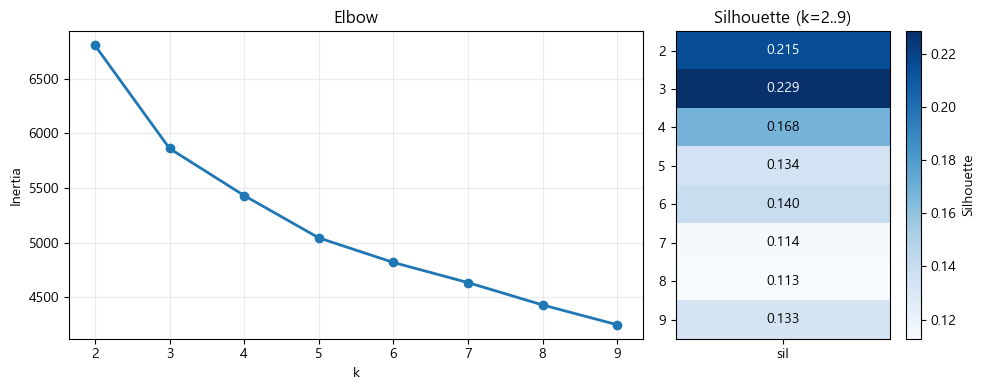

   k  silhouette
0  2    0.215289
1  3    0.228501
2  4    0.167692
3  5    0.134018
4  6    0.139598
5  7    0.114044
6  8    0.112792
7  9    0.133261


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Z_q1 = df_embed_q1[embed_cols].values

ks = range(2, 10)
inertias_q1 = []
sils_q1 = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    lab = km.fit_predict(Z_q1)
    inertias_q1.append(km.inertia_)
    sils_q1.append(silhouette_score(Z_q1, lab))

sil_df_q1 = pd.DataFrame({"k": list(ks), "silhouette": sils_q1})

# --- 한 그림에 나란히 배치 ---
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(10, 4),
    gridspec_kw={"width_ratios": [2.2, 1.0]}
)

# Elbow
ax1.plot(list(ks), inertias_q1, marker="o", color="tab:blue", linewidth=2)
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow")
ax1.grid(alpha=0.25)

# Silhouette Heatmap
heat = sil_df_q1["silhouette"].to_numpy().reshape(-1, 1)

vmin = float(np.min(heat))
vmax = float(np.max(heat))

im = ax2.imshow(
    heat,
    aspect="auto",
    cmap="Blues", 
    vmin=vmin,
    vmax=vmax
)

ax2.set_yticks(np.arange(len(sil_df_q1)))
ax2.set_yticklabels(sil_df_q1["k"])
ax2.set_xticks([0])
ax2.set_xticklabels(["sil"])

ax2.set_title("Silhouette (k=2..9)")

for i, v in enumerate(sil_df_q1["silhouette"].to_numpy()):
    ax2.text(
        0, i, f"{v:.3f}",
        ha="center", va="center",
        color="black" if (v - vmin) / (vmax - vmin + 1e-12) < 0.65 else "white",
        fontsize=10
    )

cbar = fig.colorbar(im, ax=ax2, fraction=0.12, pad=0.06)
cbar.set_label("Silhouette")

plt.tight_layout()
plt.show()

print(sil_df_q1)


In [587]:
best_k_q1 = ks[np.argmax(sils_q1)]

kmeans_q1 = KMeans(
    n_clusters=best_k_q1,
    random_state=123,
    n_init=10
)

df_embed_q1["cluster"] = kmeans_q1.fit_predict(Z_q1)

print(df_embed_q1["cluster"].value_counts().sort_index())


cluster
0    164
1     73
2     31
Name: count, dtype: int64


In [604]:
df_embed_q1.groupby("cluster")[embed_cols].mean()

,STRUCT_PC1,STRUCT_PC2,STRUCT_PC3,ACCESS_PC1,ACCESS_PC2,ACCESS_PC3,RESIDENT_PC1,RESIDENT_PC2,AGE_PC1,AGE_PC2,AGE_PC3,PURPOSE_PC1,PURPOSE_PC2,OD_MODAL_PC1,OD_MODAL_PC2,STAY_TIME_PC1,STAY_TIME_PC2,MCA_MC1,MCA_MC2,MCA_MC3
cluster,,,,,,,,,,,,,,,,,,,,
0,-0.427163,0.341993,-0.008617,0.203785,0.148214,-0.139723,-0.729619,-0.142534,-0.448012,-0.152209,0.241096,1.058917,0.240364,0.297191,0.185811,0.606948,0.095910,-0.011322,-0.102148,-0.091864
1,-0.302182,-0.647722,0.364668,-1.738723,-0.243567,0.163156,1.674940,-0.662315,0.406541,1.171897,-0.857698,-1.705469,-1.407360,-1.882912,-0.132689,-1.060067,0.306072,-0.159957,-0.079401,-0.081487
2,1.332302,0.956400,-0.609600,2.448265,-0.566507,0.265613,0.455398,1.516099,0.597308,-0.341050,0.387276,-2.627352,1.939200,1.312365,-0.016028,-1.121303,-0.968327,0.671079,0.311762,-0.029284


In [605]:
df_embed_q1.groupby("cluster")[embed_cols].median()

,STRUCT_PC1,STRUCT_PC2,STRUCT_PC3,ACCESS_PC1,ACCESS_PC2,ACCESS_PC3,RESIDENT_PC1,RESIDENT_PC2,AGE_PC1,AGE_PC2,AGE_PC3,PURPOSE_PC1,PURPOSE_PC2,OD_MODAL_PC1,OD_MODAL_PC2,STAY_TIME_PC1,STAY_TIME_PC2,MCA_MC1,MCA_MC2,MCA_MC3
cluster,,,,,,,,,,,,,,,,,,,,
0,-0.252115,0.453345,0.129707,0.161463,0.197991,-0.101105,-0.697651,-0.219746,-0.629759,-0.258320,0.315605,1.175107,-0.066092,0.295373,0.132273,0.924556,0.166139,0.018107,-0.381164,-0.125629
1,-0.284580,-0.610563,0.507167,-1.820657,-0.314529,0.079268,1.699093,-0.689132,0.385679,1.339569,-0.901450,-1.740491,-1.542786,-2.039545,-0.159948,-1.019423,0.238014,0.018107,-0.381164,-0.125629
2,1.381157,1.220028,-0.530264,2.750930,-0.693520,0.407807,0.330490,1.489728,0.589163,-0.723578,0.680526,-1.609102,2.269068,1.415257,-0.173158,-0.908196,-1.027953,0.018107,-0.381164,-0.125629


In [601]:
cluster_summary_q1 = (
    df_embed_q1
    .groupby("cluster")[embed_cols]
    .mean()
)

print(cluster_summary_q1)

         STRUCT_PC1  STRUCT_PC2  STRUCT_PC3  ACCESS_PC1  ACCESS_PC2  \
cluster                                                               
0         -0.427163    0.341993   -0.008617    0.203785    0.148214   
1         -0.302182   -0.647722    0.364668   -1.738723   -0.243567   
2          1.332302    0.956400   -0.609600    2.448265   -0.566507   

         ACCESS_PC3  RESIDENT_PC1  RESIDENT_PC2   AGE_PC1   AGE_PC2   AGE_PC3  \
cluster                                                                         
0         -0.139723     -0.729619     -0.142534 -0.448012 -0.152209  0.241096   
1          0.163156      1.674940     -0.662315  0.406541  1.171897 -0.857698   
2          0.265613      0.455398      1.516099  0.597308 -0.341050  0.387276   

         PURPOSE_PC1  PURPOSE_PC2  OD_MODAL_PC1  OD_MODAL_PC2  STAY_TIME_PC1  \
cluster                                                                        
0           1.058917     0.240364      0.297191      0.185811       0.606948  

#### 시각화

In [616]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

def kde_gaussian_1d(x, grid, bw=None):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = x.size
    if n < 2:
        return np.zeros_like(grid)

    if bw is None:
        std = np.std(x, ddof=1)
        iqr = np.subtract(*np.percentile(x, [75, 25]))
        sigma = min(std, iqr / 1.34) if iqr > 0 else std
        bw = 0.9 * sigma * (n ** (-1/5))
        if bw <= 0 or np.isnan(bw):
            bw = 1.0

    diff = (grid[:, None] - x[None, :]) / bw
    dens = np.exp(-0.5 * diff**2).sum(axis=1) / (n * bw * np.sqrt(2*np.pi))
    return dens

In [617]:
def plot_density_overlay_by_cluster_ax(
    df, feature, cluster_col="cluster", ax=None, fill=False
):
    if ax is None:
        ax = plt.gca()

    x_all = df[feature].dropna().values
    if len(x_all) < 2:
        return

    lo, hi = np.percentile(x_all, [1, 99])
    grid = np.linspace(lo, hi, 300)

    for cl in sorted(df[cluster_col].unique()):
        x = df.loc[df[cluster_col] == cl, feature].dropna().values
        if len(x) < 2:
            continue

        dens = kde_gaussian_1d(x, grid)
        ax.plot(grid, dens, label=f"cluster {cl}")
        if fill:
            ax.fill_between(grid, dens, alpha=0.2)

    ax.axvline(0, linestyle="--", color="gray", alpha=0.6)
    ax.set_title(feature)
    ax.grid(True)


TOP feats: ['ACCESS_PC1', 'PURPOSE_PC1', 'PURPOSE_PC2', 'OD_MODAL_PC1', 'RESIDENT_PC1', 'RESIDENT_PC2', 'STRUCT_PC1', 'STAY_TIME_PC1', 'STRUCT_PC2', 'AGE_PC2', 'STAY_TIME_PC2', 'AGE_PC3', 'AGE_PC1', 'STRUCT_PC3', 'MCA_MC1', 'ACCESS_PC2', 'MCA_MC2', 'ACCESS_PC3', 'OD_MODAL_PC2', 'MCA_MC3']


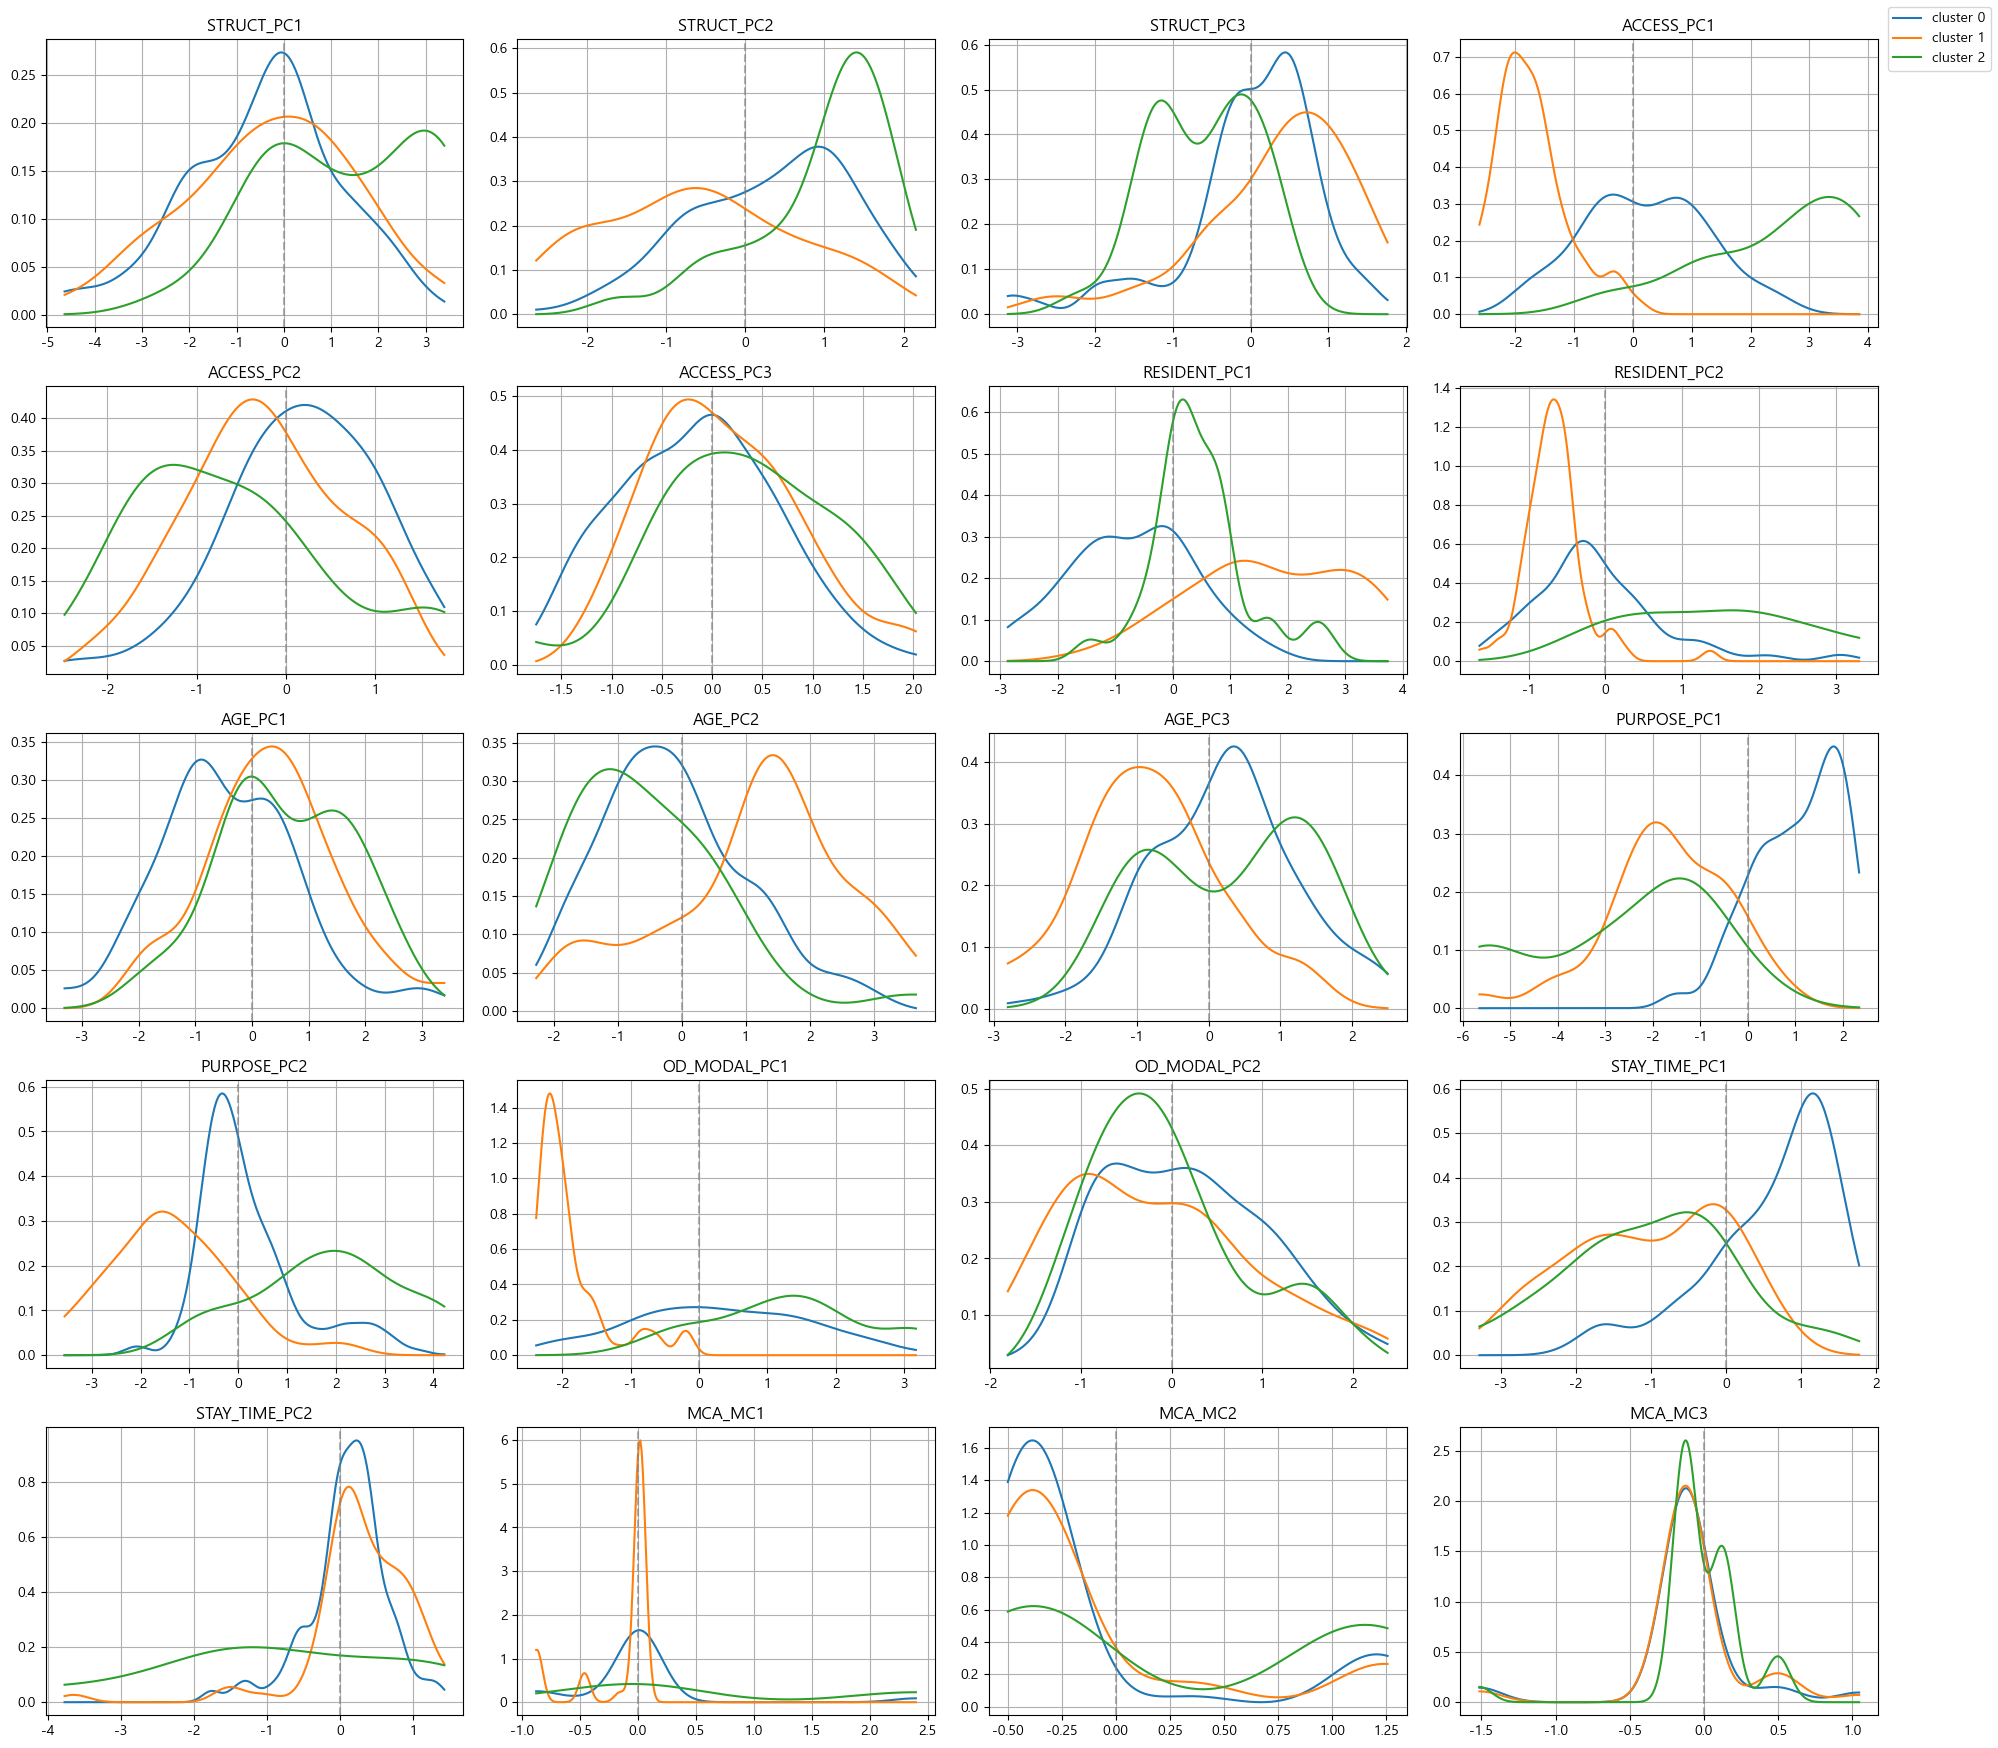

In [600]:
gap = (df_embed_q1.groupby("cluster")[embed_cols].mean().max()
       - df_embed_q1.groupby("cluster")[embed_cols].mean().min()).sort_values(ascending=False)

topN = 20
top_feats = gap.head(topN).index.tolist()
print("TOP feats:", top_feats)


ncols = 4
nrows = int(np.ceil(len(top_feats) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(5*ncols, 3.5*nrows),
    sharey=False
)

axes = axes.flatten()

for i, feat in enumerate(embed_cols):
    plot_density_overlay_by_cluster_ax(
        df_embed_q1,
        feat,
        cluster_col="cluster",
        ax=axes[i],
        fill=False
    )

# 남는 subplot 제거
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# 범례는 한 번만
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

In [611]:
print(cluster_summary_q1)

         STRUCT_PC1  STRUCT_PC2  STRUCT_PC3  ACCESS_PC1  ACCESS_PC2  \
cluster                                                               
0         -0.427163    0.341993   -0.008617    0.203785    0.148214   
1         -0.302182   -0.647722    0.364668   -1.738723   -0.243567   
2          1.332302    0.956400   -0.609600    2.448265   -0.566507   

         ACCESS_PC3  RESIDENT_PC1  RESIDENT_PC2   AGE_PC1   AGE_PC2   AGE_PC3  \
cluster                                                                         
0         -0.139723     -0.729619     -0.142534 -0.448012 -0.152209  0.241096   
1          0.163156      1.674940     -0.662315  0.406541  1.171897 -0.857698   
2          0.265613      0.455398      1.516099  0.597308 -0.341050  0.387276   

         PURPOSE_PC1  PURPOSE_PC2  OD_MODAL_PC1  OD_MODAL_PC2  STAY_TIME_PC1  \
cluster                                                                        
0           1.058917     0.240364      0.297191      0.185811       0.606948  

## Q2

### 클러스터링

#### 엘보우 + 실루엣

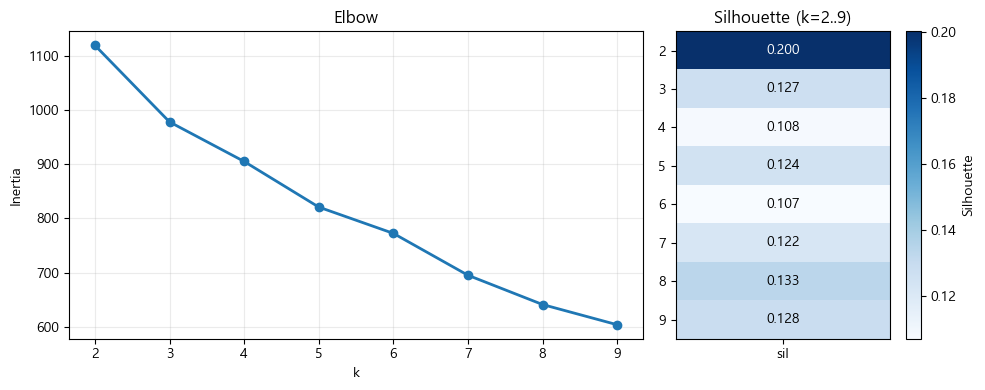

   k  silhouette
0  2    0.200068
1  3    0.126607
2  4    0.107825
3  5    0.124395
4  6    0.106910
5  7    0.122024
6  8    0.133361
7  9    0.128261


In [588]:
Z_q2 = df_embed_q2[embed_cols].values

ks = range(2, 10)
inertias_q2 = []
sils_q2 = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    lab = km.fit_predict(Z_q2)
    inertias_q2.append(km.inertia_)
    sils_q2.append(silhouette_score(Z_q2, lab))

sil_df_q2 = pd.DataFrame({"k": list(ks), "silhouette": sils_q2})

# --- 한 그림에 나란히 배치 ---
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(10, 4),
    gridspec_kw={"width_ratios": [2.2, 1.0]}
)

# Elbow
ax1.plot(list(ks), inertias_q2, marker="o", color="tab:blue", linewidth=2)
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow")
ax1.grid(alpha=0.25)

# Silhouette Heatmap
heat = sil_df_q2["silhouette"].to_numpy().reshape(-1, 1)

vmin = float(np.min(heat))
vmax = float(np.max(heat))

im = ax2.imshow(
    heat,
    aspect="auto",
    cmap="Blues",   
    vmin=vmin,
    vmax=vmax
)

ax2.set_yticks(np.arange(len(sil_df_q2)))
ax2.set_yticklabels(sil_df_q2["k"])
ax2.set_xticks([0])
ax2.set_xticklabels(["sil"])

ax2.set_title("Silhouette (k=2..9)")

for i, v in enumerate(sil_df_q2["silhouette"].to_numpy()):
    ax2.text(
        0, i, f"{v:.3f}",
        ha="center", va="center",
        color="black" if (v - vmin) / (vmax - vmin + 1e-12) < 0.65 else "white",
        fontsize=10
    )


cbar = fig.colorbar(im, ax=ax2, fraction=0.12, pad=0.06)
cbar.set_label("Silhouette")

plt.tight_layout()
plt.show()

print(sil_df_q2)


In [589]:
best_k_q2 = ks[np.argmax(sils_q2)]

kmeans_q2 = KMeans(
    n_clusters=best_k_q2,
    random_state=123,
    n_init=10
)

df_embed_q2["cluster"] = kmeans_q2.fit_predict(Z_q2)

print(df_embed_q2["cluster"].value_counts().sort_index())


cluster
0    11
1    43
Name: count, dtype: int64


In [574]:
cluster_summary_q2 = (
    df_embed_q2
    .groupby("cluster")[embed_cols]
    .mean()
)

print(cluster_summary_q2)

         STRUCT_PC1  STRUCT_PC2  STRUCT_PC3  ACCESS_PC1  ACCESS_PC2  \
cluster                                                               
0          0.929350    0.192499    0.128191    1.232146    0.238968   
1          0.398656   -0.091085    0.141308    0.049875    0.298046   

         ACCESS_PC3  RESIDENT_PC1  RESIDENT_PC2   AGE_PC1   AGE_PC2   AGE_PC3  \
cluster                                                                         
0         -0.023465      1.040475      0.383116  1.812659  0.207751  0.688574   
1          0.049627     -1.322596      0.071078 -0.915291 -0.484313  0.281663   

         PURPOSE_PC1  PURPOSE_PC2  OD_MODAL_PC1  OD_MODAL_PC2  STAY_TIME_PC1  \
cluster                                                                        
0          -0.282211     1.663111      0.514198      0.169876      -0.863809   
1           0.878852    -0.023112      0.597005     -0.129060       0.815674   

         STAY_TIME_PC2   MCA_MC1   MCA_MC2   MCA_MC3  
cluster       

#### 시각화

TOP feats: ['AGE_PC1', 'RESIDENT_PC1', 'PURPOSE_PC2', 'STAY_TIME_PC1', 'ACCESS_PC1', 'PURPOSE_PC1', 'AGE_PC2', 'STRUCT_PC1', 'AGE_PC3', 'MCA_MC1', 'RESIDENT_PC2', 'OD_MODAL_PC2', 'STRUCT_PC2', 'STAY_TIME_PC2', 'MCA_MC2', 'OD_MODAL_PC1', 'ACCESS_PC3', 'ACCESS_PC2', 'STRUCT_PC3', 'MCA_MC3']


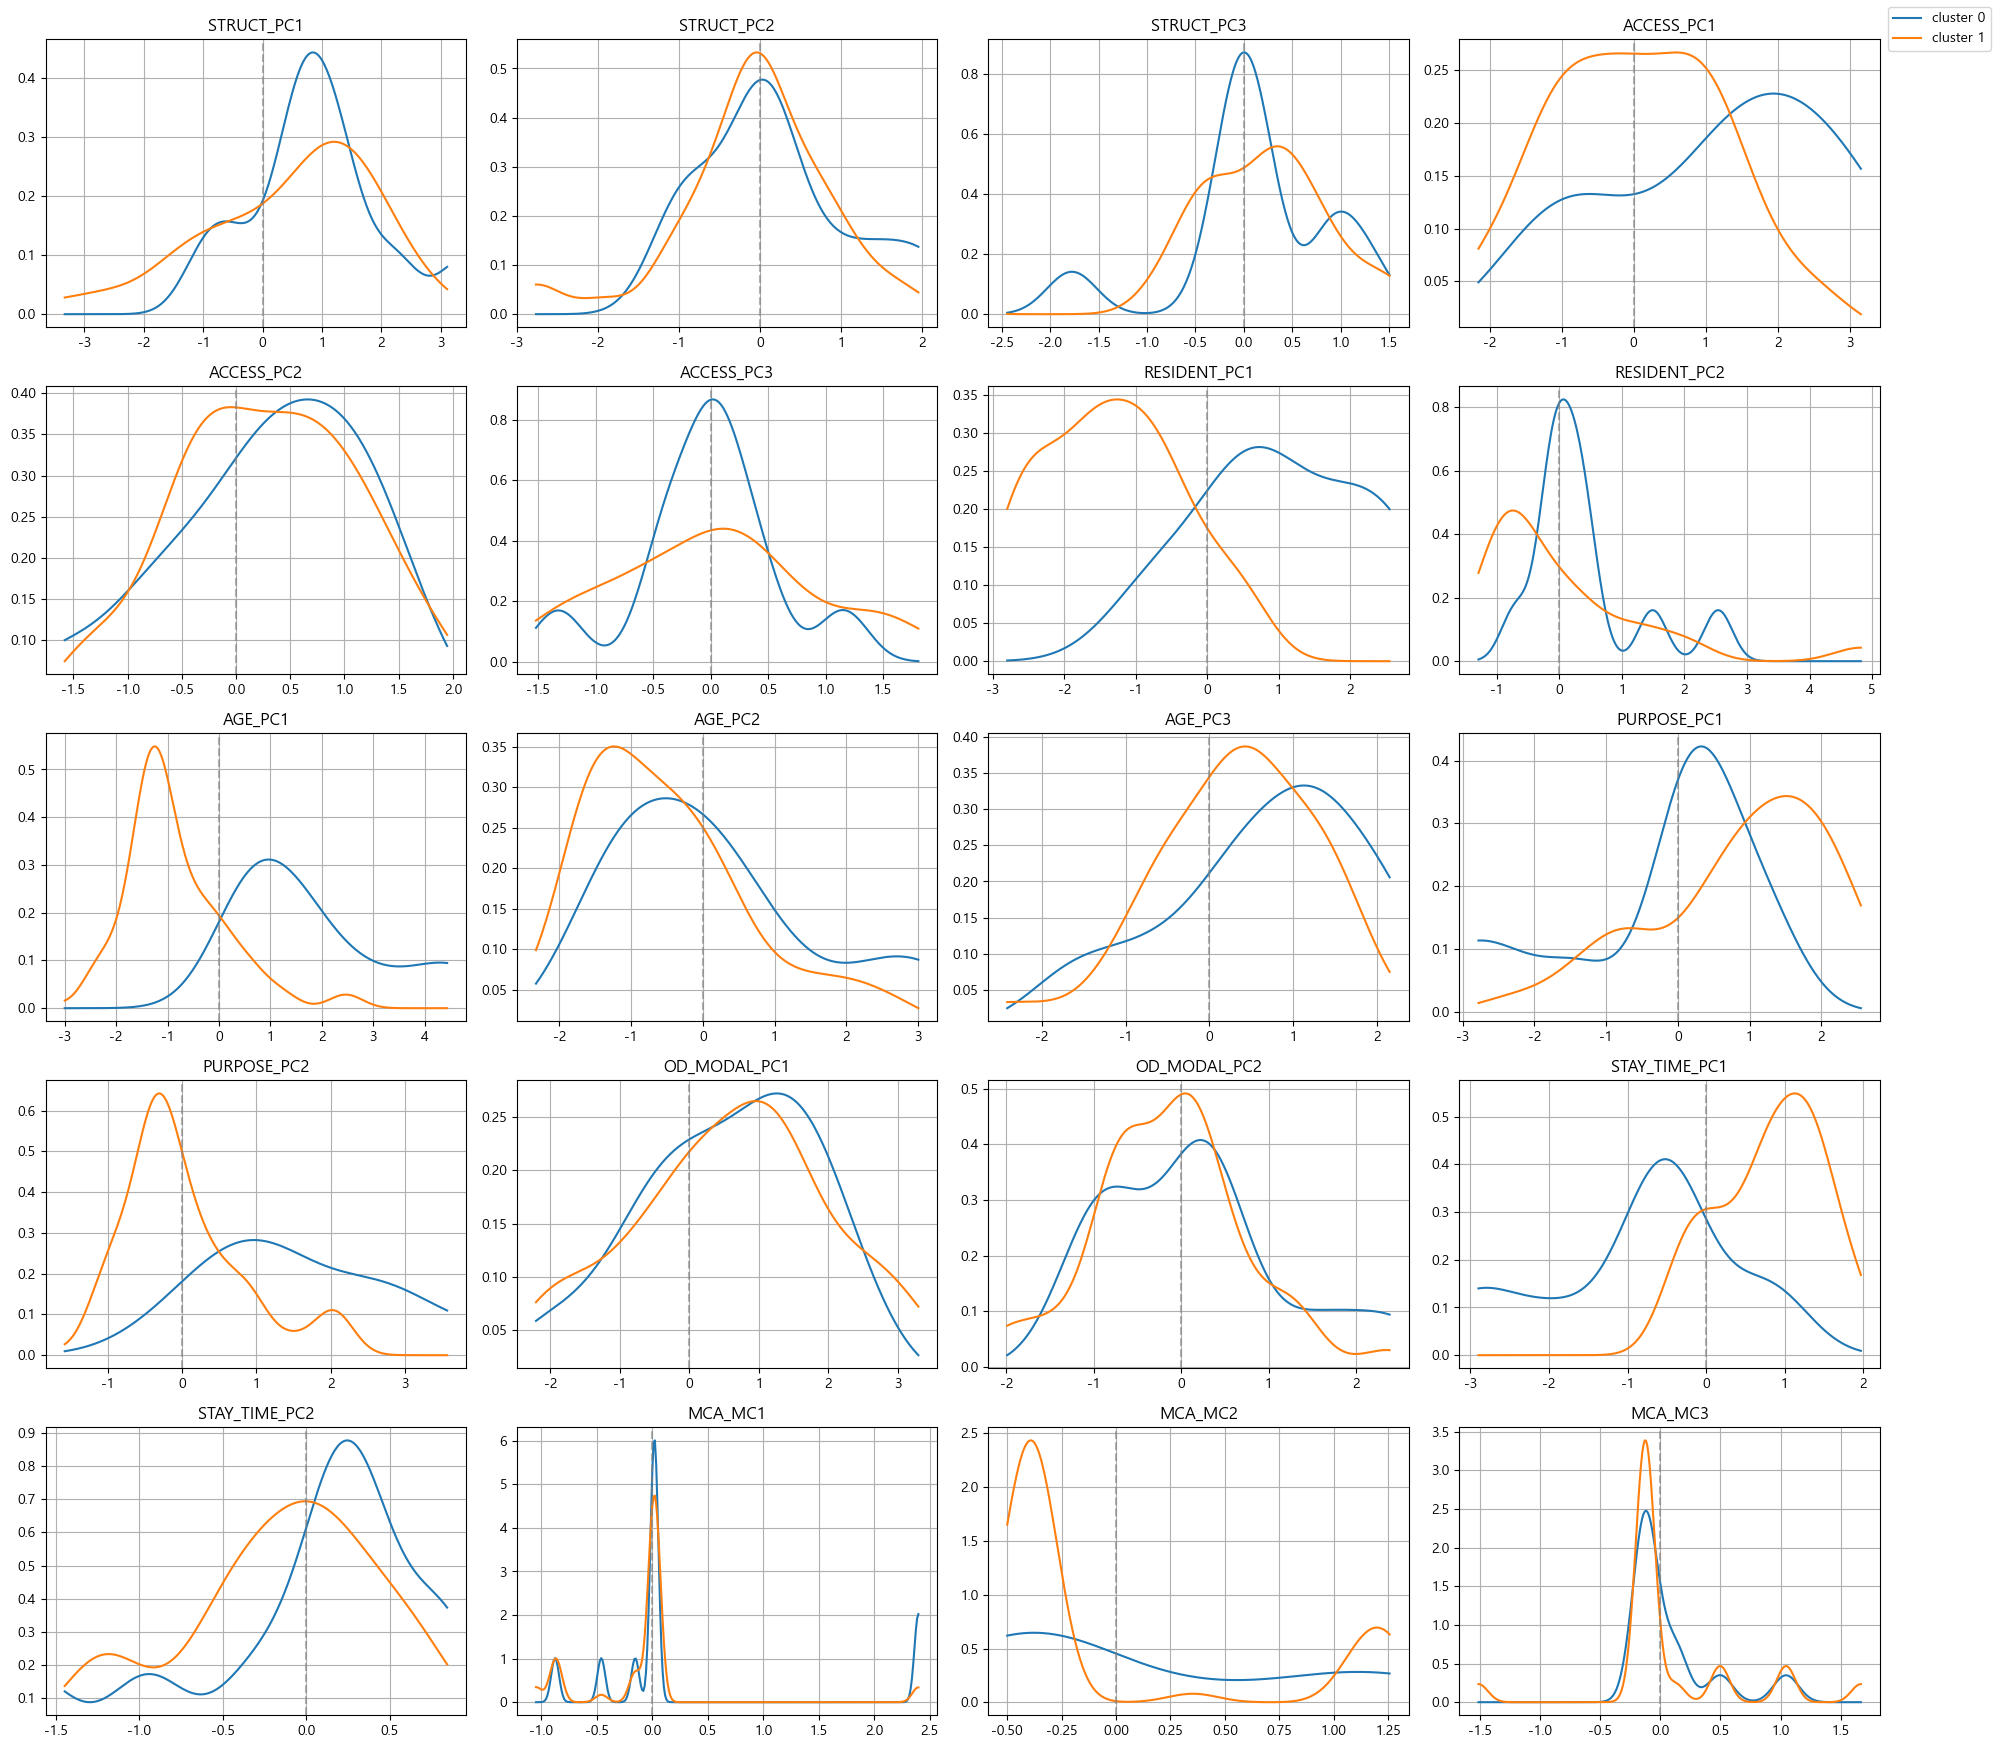

In [619]:
gap_q2 = (df_embed_q2.groupby("cluster")[embed_cols].mean().max()
       - df_embed_q2.groupby("cluster")[embed_cols].mean().min()).sort_values(ascending=False)

topN_q2 = 20
top_feats_q2 = gap_q2.head(topN_q2).index.tolist()
print("TOP feats:", top_feats_q2)


ncols_q2 = 4
nrows_q2 = int(np.ceil(len(top_feats_q2) / ncols_q2))

fig_q2, axes_q2 = plt.subplots(
    nrows_q2, ncols_q2,
    figsize=(5*ncols_q2, 3.5*nrows_q2),
    sharey=False
)

axes_q2 = axes_q2.flatten()

for i, feat in enumerate(embed_cols):
    plot_density_overlay_by_cluster_ax(
        df_embed_q2,
        feat,
        cluster_col="cluster",
        ax=axes_q2[i],
        fill=False
    )

# 남는 subplot 제거
for j in range(i+1, len(axes_q2)):
    fig.delaxes(axes_q2[j])

# 범례는 한 번만
handles_q2, labels_q2 = axes_q2[0].get_legend_handles_labels()
fig_q2.legend(handles_q2, labels_q2, loc="upper right")

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

In [612]:
df_embed_q2.groupby("cluster")[embed_cols].mean()

,STRUCT_PC1,STRUCT_PC2,STRUCT_PC3,ACCESS_PC1,ACCESS_PC2,ACCESS_PC3,RESIDENT_PC1,RESIDENT_PC2,AGE_PC1,AGE_PC2,AGE_PC3,PURPOSE_PC1,PURPOSE_PC2,OD_MODAL_PC1,OD_MODAL_PC2,STAY_TIME_PC1,STAY_TIME_PC2,MCA_MC1,MCA_MC2,MCA_MC3
cluster,,,,,,,,,,,,,,,,,,,,
0,0.929350,0.192499,0.128191,1.232146,0.238968,-0.023465,1.040475,0.383116,1.812659,0.207751,0.688574,-0.282211,1.663111,0.514198,0.169876,-0.863809,0.016555,0.310312,0.094451,0.083924
1,0.398656,-0.091085,0.141308,0.049875,0.298046,0.049627,-1.322596,0.071078,-0.915291,-0.484313,0.281663,0.878852,-0.023112,0.597005,-0.129060,0.815674,-0.133836,-0.071930,-0.008892,0.072036


In [613]:
df_embed_q2.groupby("cluster")[embed_cols].median()

,STRUCT_PC1,STRUCT_PC2,STRUCT_PC3,ACCESS_PC1,ACCESS_PC2,ACCESS_PC3,RESIDENT_PC1,RESIDENT_PC2,AGE_PC1,AGE_PC2,AGE_PC3,PURPOSE_PC1,PURPOSE_PC2,OD_MODAL_PC1,OD_MODAL_PC2,STAY_TIME_PC1,STAY_TIME_PC2,MCA_MC1,MCA_MC2,MCA_MC3
cluster,,,,,,,,,,,,,,,,,,,,
0,0.896815,0.104805,0.006268,1.431207,0.243179,-0.013391,0.803146,0.143951,1.464286,-0.070532,0.894342,0.214886,1.137843,0.618947,0.247117,-0.529364,0.252838,0.018107,-0.381164,-0.125629
1,0.809536,-0.042356,0.239375,0.027002,0.309435,0.055516,-1.391983,-0.359742,-1.196348,-0.638431,0.367049,1.077737,-0.251913,0.693350,-0.021888,0.947541,-0.082244,0.018107,-0.381164,-0.125629


## 각 클러스터 시각화

In [577]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

def viz_pca_2d3d_from_embed(df_embed, embed_cols, cluster_col="cluster", title_prefix=""):
    X = df_embed[embed_cols].copy()
    X = X.replace([np.inf, -np.inf], np.nan).dropna()
    dfv = df_embed.loc[X.index].copy()

    scaler = StandardScaler()
    Xs = scaler.fit_transform(X.values)

    pca2 = PCA(n_components=3, random_state=88)
    Z = pca2.fit_transform(Xs)

    # 2D
    plt.figure(figsize=(6,5))
    for k in sorted(dfv[cluster_col].unique()):
        idx = dfv[cluster_col] == k
        plt.scatter(Z[idx,0], Z[idx,1], alpha=0.6, s=40, label=f"cluster {k}")
    plt.xlabel("VIS_PC1")
    plt.ylabel("VIS_PC2")
    plt.title(f"{title_prefix} 2D (PCA on PC/MC)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3D
    fig = plt.figure(figsize=(7,6))
    ax = fig.add_subplot(111, projection="3d")
    for k in sorted(dfv[cluster_col].unique()):
        idx = dfv[cluster_col] == k
        ax.scatter(Z[idx,0], Z[idx,1], Z[idx,2], alpha=0.6, s=40, label=f"cluster {k}")
    ax.set_xlabel("VIS_PC1")
    ax.set_ylabel("VIS_PC2")
    ax.set_zlabel("VIS_PC3")
    ax.set_title(f"{title_prefix} 3D (PCA on PC/MC)")
    ax.legend()
    plt.tight_layout()
    plt.show()

### Q1

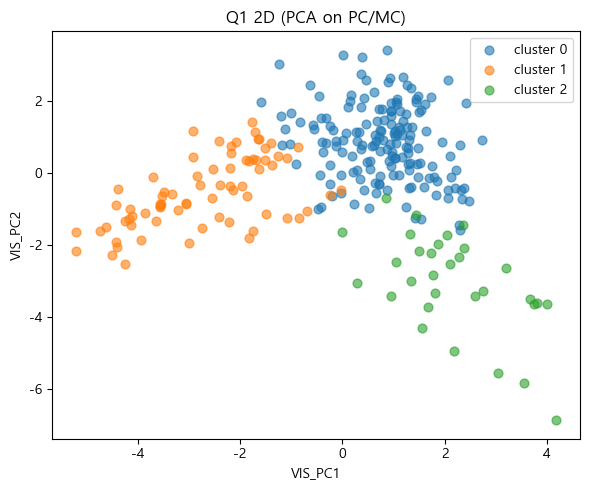

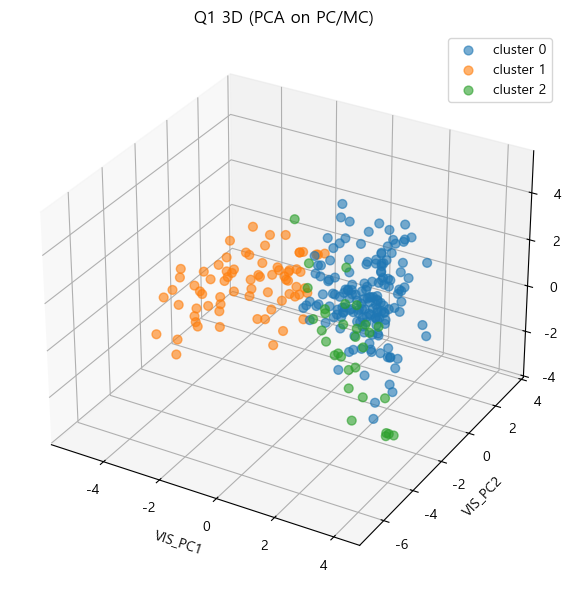

In [578]:
viz_pca_2d3d_from_embed(df_embed_q1, embed_cols, cluster_col="cluster", title_prefix="Q1")


### Q2

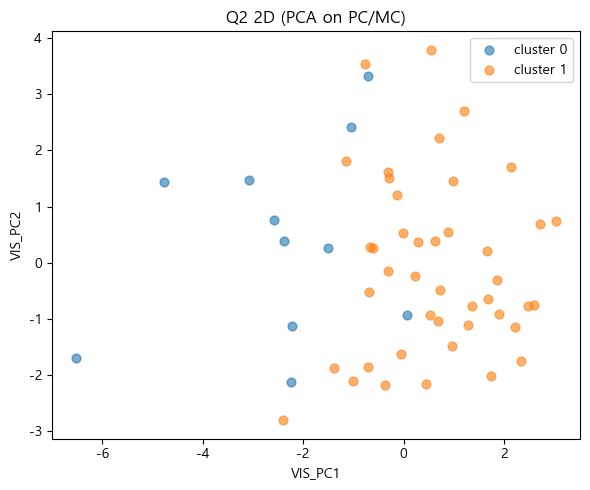

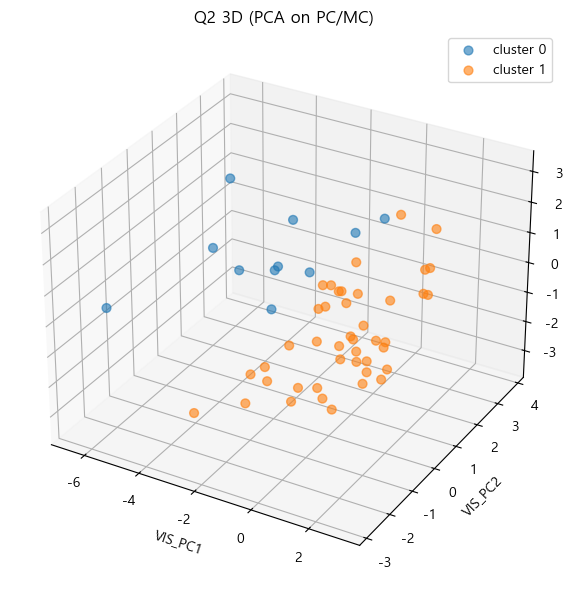

In [579]:
viz_pca_2d3d_from_embed(df_embed_q2, embed_cols, cluster_col="cluster", title_prefix="Q2")

## 저장

In [635]:
df_q1 = df_embed_q1.join(
    df_od_out[["행정기관코드", "시장명", "시도", "시군구"]]
)

df_q2 = df_embed_q2.join(
    df_od_out[["행정기관코드", "시장명", "시도", "시군구"]]
)


In [636]:
front_cols = ["행정기관코드", "시장명", "시도", "시군구"]
other_cols_q1 = [c for c in df_q1.columns if c not in front_cols]
other_cols_q2 = [c for c in df_q2.columns if c not in front_cols]

df_q1 = df_q1[front_cols + other_cols_q1]
df_q2 = df_q2[front_cols + other_cols_q2]

In [ ]:
df_q1.to_csv(r"C:\Users\legen\Desktop\Lab Project\BC\data\df_embed_q1.csv", encoding = 'utf-8-sig', index_label=False)
df_q2.to_csv(r"C:\Users\legen\Desktop\Lab Project\BC\data\df_embed_q2.csv", encoding = 'utf-8-sig', index_label=False)